In [ ]:
%pip install catboost

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/Bank Customer Churn Prediction.csv")

In [ ]:
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.isnull().sum()

,0
customer_id,0
credit_score,0
country,0
gender,0
age,0
tenure,0
balance,0
products_number,0
credit_card,0
active_member,0


## Exploratory Data Analysis (EDA)

Let's first inspect the data types and check for non-null values using `info()` and then look at the descriptive statistics using `describe()`.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [ ]:
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


Next, let's look at the distribution of our target variable, `churn`.

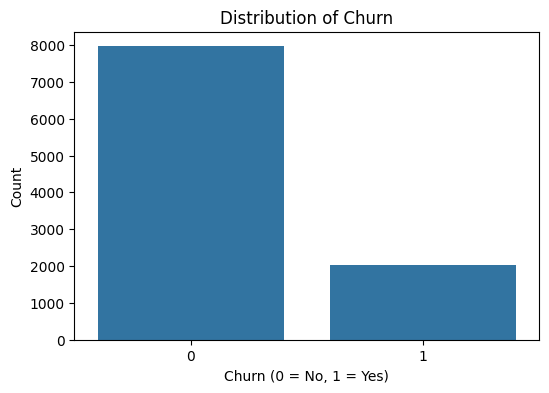

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x='churn', data=df)
plt.title('Distribution of Churn')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

Now, let's visualize the distributions of some numerical features like `age`, `credit_score`, `balance`, and `estimated_salary` to understand their spread and detect potential outliers.

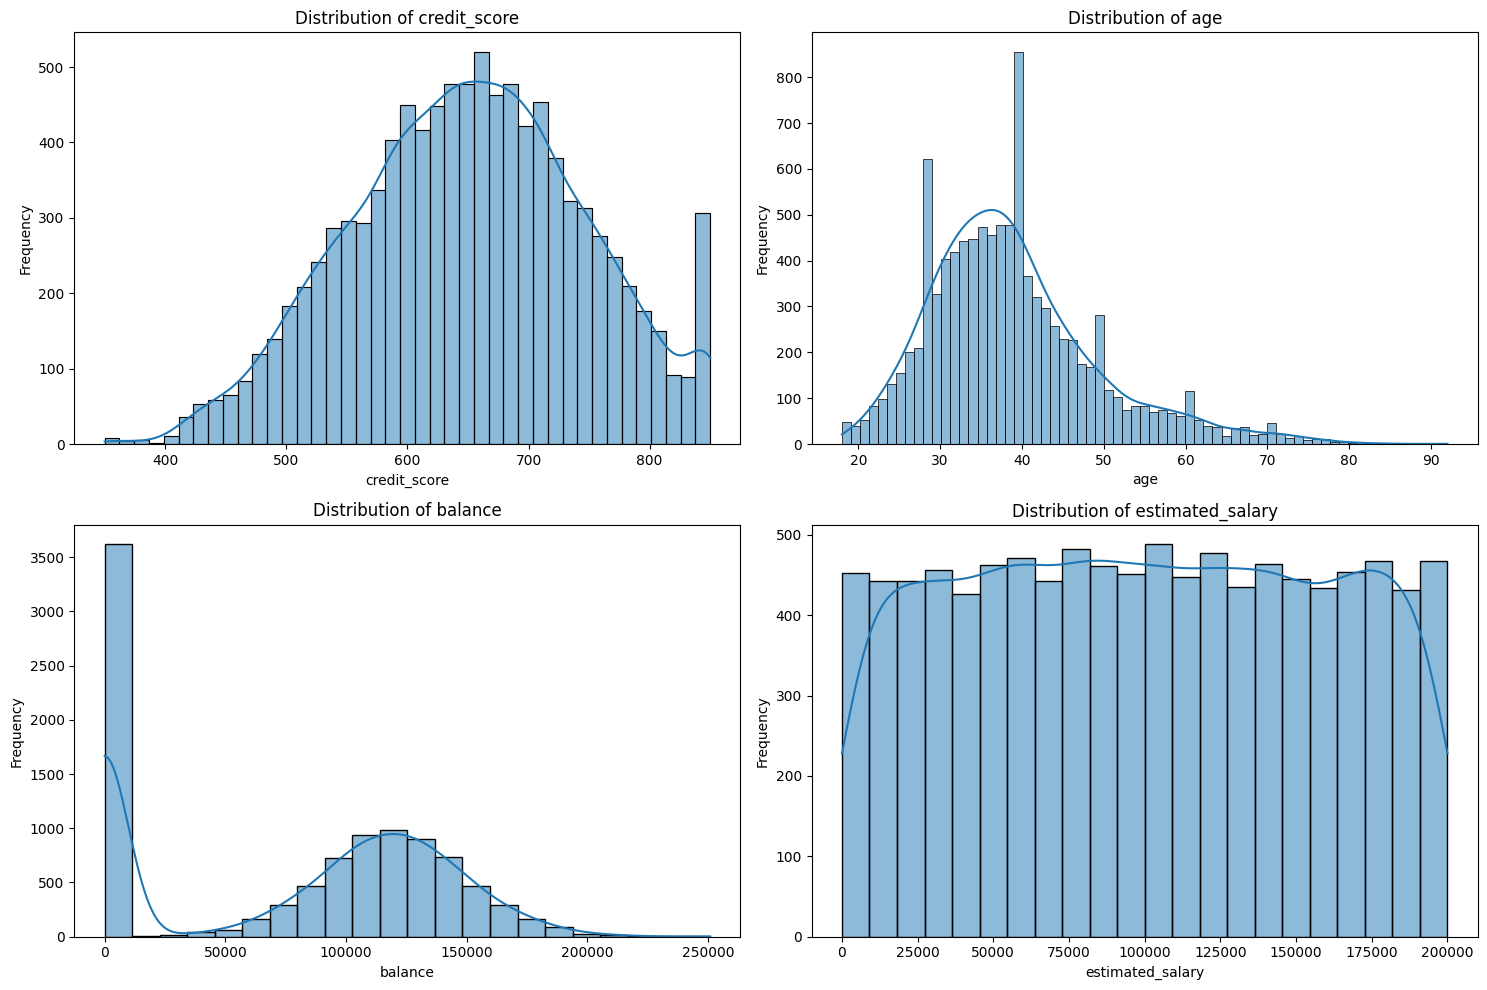

In [ ]:
numerical_features = ['credit_score', 'age', 'balance', 'estimated_salary']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(2, 2, i+1)
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Categorical Features Analysis

Let's analyze the `country` and `gender` features in relation to `churn` using countplots to see if there are any noticeable differences in churn rates across these categories.

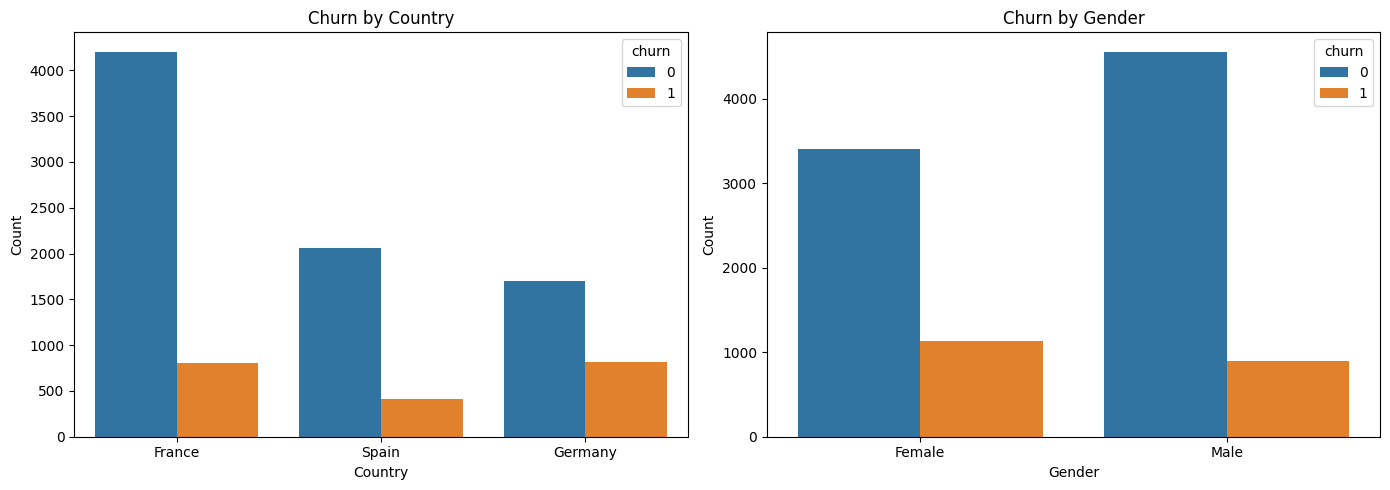

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x='country', hue='churn', data=df, ax=axes[0])
axes[0].set_title('Churn by Country')
axes[0].set_xlabel('Country')
axes[0].set_ylabel('Count')

sns.countplot(x='gender', hue='churn', data=df, ax=axes[1])
axes[1].set_title('Churn by Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

### Churn Percentage by Number of Products

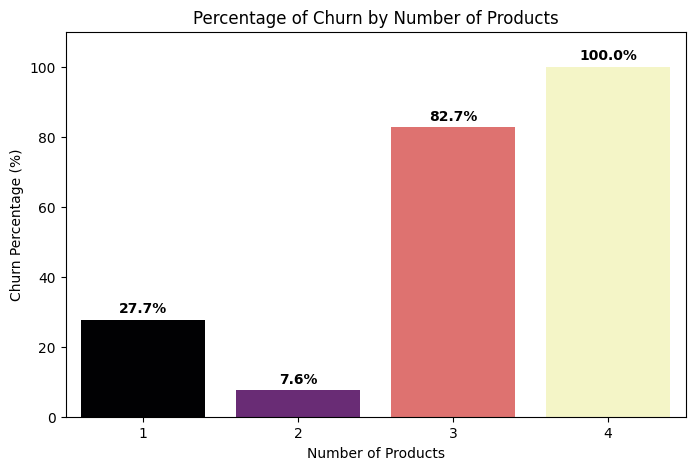

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate churn percentage per products_number
churn_per_product = df.groupby('products_number')['churn'].mean() * 100
churn_per_product = churn_per_product.reset_index(name='churn_percentage')

plt.figure(figsize=(8, 5))
# Updated to use hue=products_number and legend=False to fix the FutureWarning
sns.barplot(x='products_number', y='churn_percentage', data=churn_per_product, palette='magma', hue='products_number', legend=False)
plt.title('Percentage of Churn by Number of Products')
plt.xlabel('Number of Products')
plt.ylabel('Churn Percentage (%)')
plt.ylim(0, 110)

# Adding text labels on top of bars
for i, row in churn_per_product.iterrows():
    plt.text(i, row.churn_percentage + 2, f'{row.churn_percentage:.1f}%', ha='center', weight='bold')

plt.show()

### Correlation Matrix for Numerical Features

Finally, let's look at the correlation matrix for the numerical features to understand how they relate to each other and to the `churn` variable.

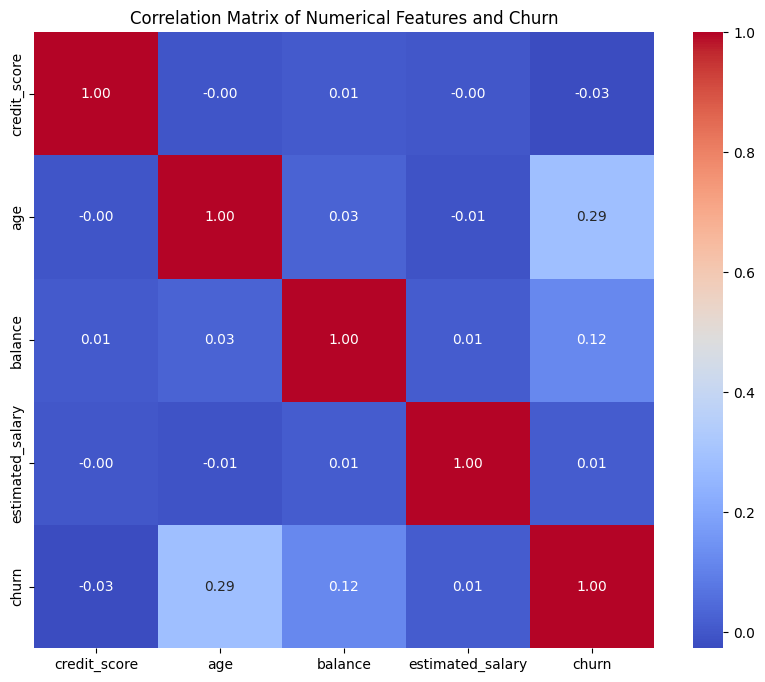

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_features + ['churn']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features and Churn')
plt.show()

## Feature Engineering: One-Hot Encoding

We will now apply one-hot encoding to the categorical features (`country` and `gender`) using `pd.get_dummies()`. This process creates new binary columns for each category, which is necessary for many machine learning algorithms.

In [ ]:
df = pd.get_dummies(df, columns=['country', 'gender'], drop_first=True)
display(df.head())

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_Germany,country_Spain,gender_Male
0,15634602,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,15647311,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,15619304,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,15701354,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,15737888,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


## Feature Scaling: StandardScaler

We will now scale the numerical features in our DataFrame using `StandardScaler` from `sklearn.preprocessing`. This technique transforms the data so that it has a mean of 0 and a standard deviation of 1. This helps in equalizing the influence of all features on the model.

In [ ]:
# Reload to ensure we have clean original values for tenure and products_number
df = pd.read_csv("/content/Bank Customer Churn Prediction.csv")

# Re-apply One-Hot Encoding
df = pd.get_dummies(df, columns=['country', 'gender'], drop_first=True)

# Scale only the requested numerical columns
from sklearn.preprocessing import StandardScaler
numerical_cols_to_scale = ['credit_score', 'age', 'balance', 'estimated_salary']
scaler = StandardScaler()
df[numerical_cols_to_scale] = scaler.fit_transform(df[numerical_cols_to_scale])

display(df.head())

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_Germany,country_Spain,gender_Male
0,15634602,-0.326221,0.293517,2,-1.225848,1,1,1,0.021886,1,False,False,False
1,15647311,-0.440036,0.198164,1,0.117350,1,0,1,0.216534,0,False,True,False
2,15619304,-1.536794,0.293517,8,1.333053,3,1,0,0.240687,1,False,False,False
3,15701354,0.501521,0.007457,1,-1.225848,2,0,0,-0.108918,0,False,False,False
4,15737888,2.063884,0.388871,2,0.785728,1,1,1,-0.365276,0,False,True,False


## Model Development and Evaluation
We'll split the data, train the models, and evaluate them.

Logistic Regression AUC Score: 0.7748
Random Forest AUC Score: 0.8525
Gradient Boosting AUC Score: 0.8708
XGBoost AUC Score: 0.8328
CatBoost AUC Score: 0.8622


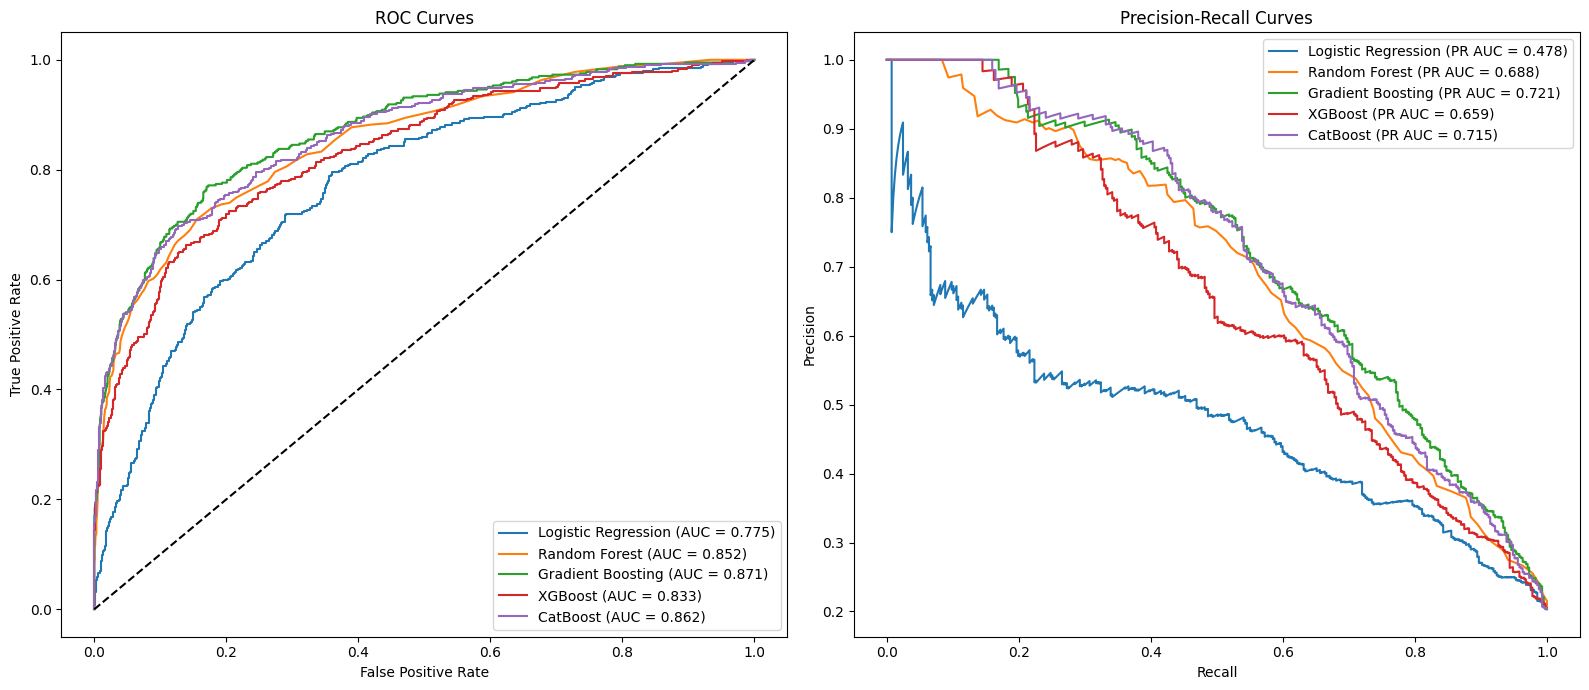

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt
import pandas as pd

# Prepare features and target
X = df.drop(['customer_id', 'churn'], axis=1)
y = df['churn']

# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize models (added Gradient Boosting)
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42),
    'CatBoost': CatBoostClassifier(verbose=0, random_state=42)
}

# Plotting Setup
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

for name, model in models.items():
    model.fit(X_train, y_train)
    y_probs = model.predict_proba(X_test)[:, 1]
    auc_score = roc_auc_score(y_test, y_probs)
    print(f'{name} AUC Score: {auc_score:.4f}')

    fpr, tpr, _ = roc_curve(y_test, y_probs)
    ax1.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})')

    precision, recall, _ = precision_recall_curve(y_test, y_probs)
    pr_auc = auc(recall, precision)
    ax2.plot(recall, precision, label=f'{name} (PR AUC = {pr_auc:.3f})')

ax1.plot([0, 1], [0, 1], 'k--')
ax1.set_title('ROC Curves')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend()

ax2.set_title('Precision-Recall Curves')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend()

plt.tight_layout()
plt.show()

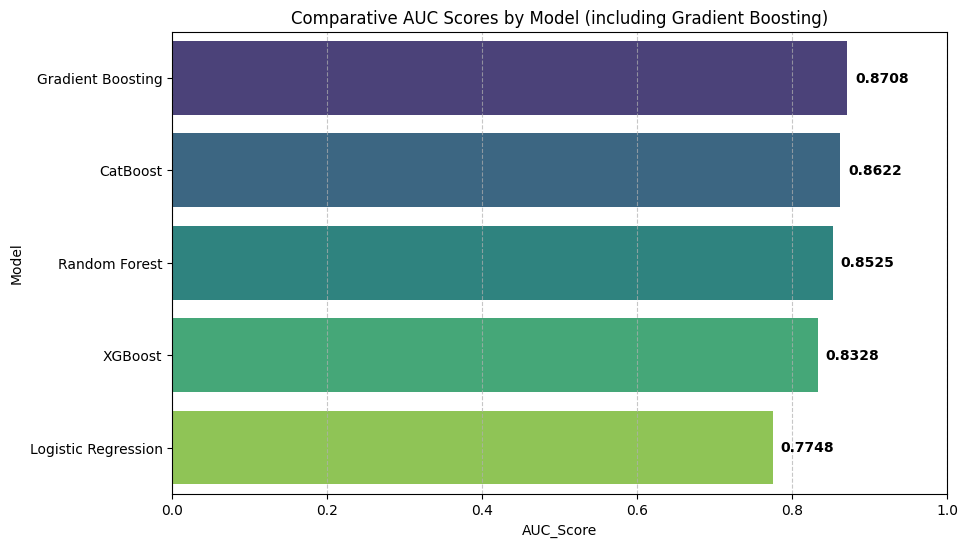

In [ ]:
# Extract updated AUC scores for visualization
auc_results = {}
for name, model in models.items():
    y_probs = model.predict_proba(X_test)[:, 1]
    auc_results[name] = roc_auc_score(y_test, y_probs)

auc_df = pd.DataFrame(list(auc_results.items()), columns=['Model', 'AUC_Score']).sort_values(by='AUC_Score', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='AUC_Score', y='Model', data=auc_df, palette='viridis', hue='Model', legend=False)
plt.title('Comparative AUC Scores by Model (including Gradient Boosting)')
plt.xlim(0, 1.0)

for i, score in enumerate(auc_df['AUC_Score']):
    plt.text(score + 0.01, i, f'{score:.4f}', va='center', fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Feature Importance (Gradient Boosting)
We will now examine which features the Gradient Boosting model relies on most heavily to make its predictions.

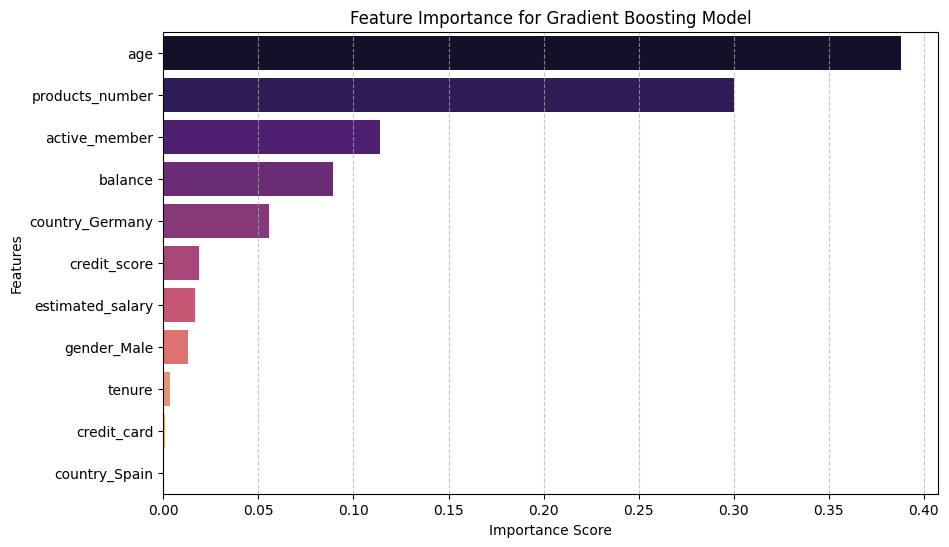

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get the Gradient Boosting model from our dictionary
gb_model = models['Gradient Boosting']

# Extract feature importances
importances = gb_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma', hue='Feature', legend=False)
plt.title('Feature Importance for Gradient Boosting Model')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## Hyperparameter Tuning: Gradient Boosting Classifier
We use `GridSearchCV` to systematically work through multiple combinations of parameter tunes, cross-validating as it goes to determine which gives the best performance.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=GradientBoostingClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5,
                           scoring='roc_auc',
                           n_jobs=-1,
                           verbose=1)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Get the best model
best_gb_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation AUC: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Best Cross-Validation AUC: 0.8649


In [ ]:
# Evaluate the tuned model on the test set
y_tuned_probs = best_gb_model.predict_proba(X_test)[:, 1]
tuned_auc = roc_auc_score(y_test, y_tuned_probs)
print(f"Tuned Gradient Boosting Test AUC: {tuned_auc:.4f}")

Tuned Gradient Boosting Test AUC: 0.8708


### Exporting the Model
We use the `pickle` library to save the model to a file, which allows us to load it later without retraining.

In [ ]:
import pickle
from google.colab import files

# Define the filename
model_filename = 'best_gradient_boosting_model.pkl'

# Save the model to a file
with open(model_filename, 'wb') as file:
    pickle.dump(best_gb_model, file)

print(f'Model saved successfully as {model_filename}')

# Trigger a download of the file to the local machine
files.download(model_filename)

Model saved successfully as best_gradient_boosting_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>